<a href="https://colab.research.google.com/github/Swastika-Roy/Python-concepts/blob/main/DecisonAndRandomForestRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**THE ORIGINAL IRIS DATASET IS CLASSIFICATION**

In [1]:
import pandas as pd
from sklearn.datasets import load_iris

In [2]:
iris = load_iris()
df=pd.DataFrame(iris.data,columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
x = df.drop('petal length (cm)',axis=1)
y=df['petal length (cm)']
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)
model.fit(x_train,y_train)

DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=42)

what is see?

data splitting criteria?

In [9]:
y_pred = model.predict(x_test)
residuals = y_test - y_pred

In [10]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test,y_pred)
print(mae)

0.27192727650511667


In [11]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test,y_pred)
print(mse)

0.12800500771405093


In [15]:
import numpy as np
rmse = np.sqrt(mse)
print(rmse)

0.35777787482466117


In [16]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)


In [18]:
importance = pd.DataFrame({'feature':x.columns,'importance':model.feature_importances_}).sort_values('importance',ascending=False)
importance

,feature,importance
2,petal width (cm),0.977677
0,sepal length (cm),0.022312
1,sepal width (cm),0.000011


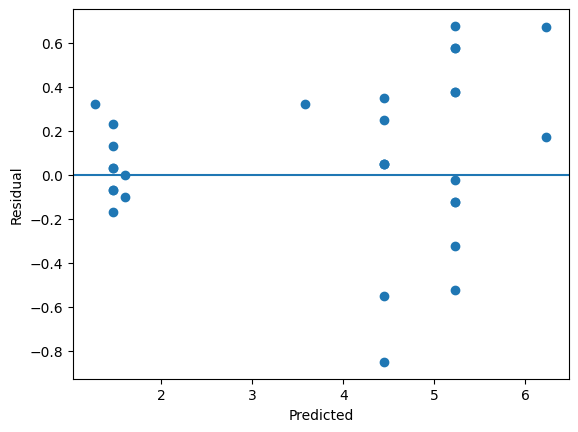

In [19]:
#Residual plot
import matplotlib.pyplot as plt
plt.scatter(y_pred,residuals)
plt.axhline(0)
plt.xlabel('Predicted')
plt.ylabel('Residual')
# plt.title('Residual Plot')
plt.show()

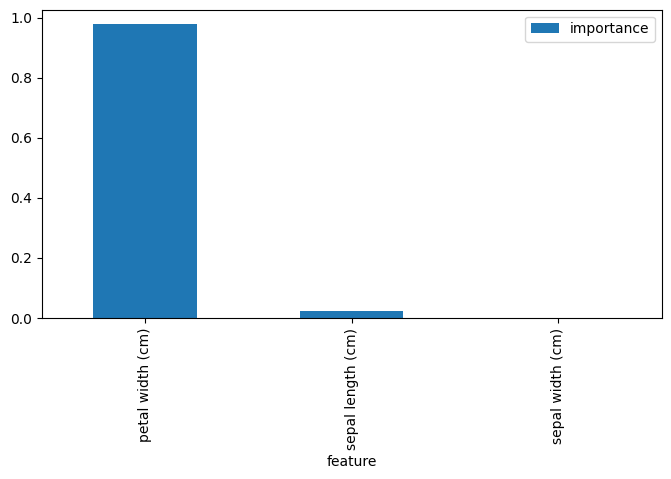

In [20]:
importance.plot(x='feature',y='importance',kind='bar',figsize=(8,4))
plt.show()

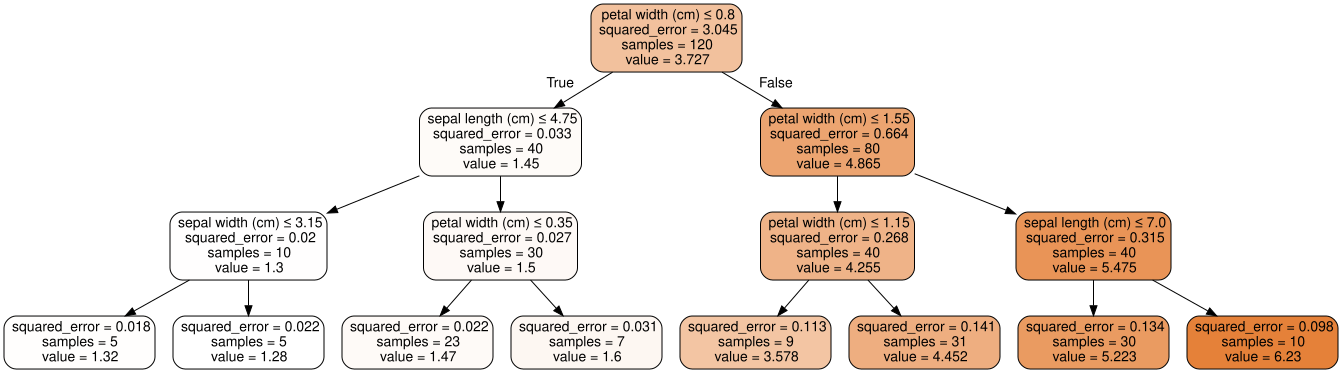

In [22]:
# !pip install graphviz
# from sklearn.tree import export_graphviz
# import graphviz

dot_data = export_graphviz(model,out_file=None,feature_names=x.columns,filled=True,rounded=True,special_characters=True)
graph = graphviz.Source(dot_data)
# graph.render('iris_decision_tree')
graph